## Notebook 3 :- Retrieval Evaluation

- Retrieval Evaluation
- Top-K
- End-To-End Pipeline Quality



In [2]:
import sys
sys.path.insert(0, '..')

from sentence_transformers import SentenceTransformer
import numpy as np
import chromadb
import requests
import json
import matplotlib.pyplot as plt
import time


d:\Gen AI Projects\Smart-Documents-Insights\venv\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange
d:\Gen AI Projects\Smart-Documents-Insights\venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


In [3]:
# Config
BACKEND_URL = 'http://localhost:8000'
CHROMA_PATH = '../chroma_db'

In [4]:
# Check Backend Health
try:
    res = requests.get(f'{BACKEND_URL}/health', timeout=3)
    print(f'Backend status: {res.json()}')
except Exception as e:
    print(f'Backend not running: {e}')
    print('Start backend first: uvicorn app.main:app --reload --port 8000')

Backend status: {'status': 'ok'}


In [10]:
import tempfile
import os
# Test document upload karo
test_doc_content = """
The French Revolution was a period of radical political change in France from 1789 to 1799.
The Revolution overthrew the monarchy and established a republic.
Napoleon Bonaparte rose to power after the Revolution and became Emperor of France.
The Eiffel Tower was built in 1889 for the World's Fair in Paris.
Paris is the capital city of France and is located along the Seine river.
Python programming language was created by Guido van Rossum in 1991.
Machine learning models require large amounts of training data.
ChromaDB is an open source vector database for AI applications.
FastAPI is a modern high performance web framework for building APIs with Python.
RAG stands for Retrieval Augmented Generation which improves LLM accuracy.
Vector embeddings capture the semantic meaning of text in a numerical format.
The transformer architecture revolutionized natural language processing in 2017.
"""

# Safe Cross-Platform Temp File Pathway
temp_dir = tempfile.gettempdir()
temp_file_path = os.path.join(temp_dir, 'eval_doc.txt')

# Save to temp file
with open(temp_file_path, 'w', encoding='utf-8') as f:
    f.write(test_doc_content * 10)

# Upload
with open(temp_file_path, 'rb') as f:
    res = requests.post(
        f'{BACKEND_URL}/api/upload',
        files={'file': ('eval_doc.txt', f, 'text/plain')}
    )

if res.status_code == 200:
    data = res.json()
    print(f'Upload success!')
    print(f'Doc ID     : {data["doc_id"]}')
    print(f'Chunks     : {data["chunks_created"]}')
else:
    print(f'Upload failed: {res.status_code} - {res.text}')

# Clean up temp file after test
if os.path.exists(temp_file_path):
    os.remove(temp_file_path)

Upload success!
Doc ID     : a5980d69-726a-47ae-8ea1-2edfbafc01b8
Chunks     : 40


In [11]:
# Eval dataset — question + expected keyword in answer
eval_questions = [
    {'q': 'What is the capital of France?',           'keyword': 'paris'},
    {'q': 'When was the French Revolution?',           'keyword': '1789'},
    {'q': 'Who created Python programming language?',  'keyword': 'guido'},
    {'q': 'What does RAG stand for?',                  'keyword': 'retrieval'},
    {'q': 'What is ChromaDB?',                         'keyword': 'vector'},
    {'q': 'When was Eiffel Tower built?',              'keyword': '1889'},
    {'q': 'What is FastAPI used for?',                 'keyword': 'api'},
    {'q': 'What are vector embeddings?',               'keyword': 'semantic'},
]

print(f'Evaluating {len(eval_questions)} questions...')

Evaluating 8 questions...


In [12]:
# Run evaluation
results = []
total_time = 0

print('Running RAG pipeline evaluation...')
print('=' * 60)

for item in eval_questions:
    start = time.time()
    res = requests.post(
        f'{BACKEND_URL}/api/query',
        json={'question': item['q']},
        timeout=30
    )
    elapsed = time.time() - start
    total_time += elapsed

    if res.status_code == 200:
        answer = res.json().get('answer', '').lower()
        passed = item['keyword'].lower() in answer
        results.append({
            'question': item['q'],
            'keyword': item['keyword'],
            'answer': answer[:100],
            'passed': passed,
            'time': elapsed
        })
        status = 'PASS' if passed else 'FAIL'
        print(f'[{status}] {item["q"][:45]:45s} ({elapsed:.1f}s)')
    else:
        print(f'[ERROR] {item["q"][:45]:45s}')
        results.append({'question': item['q'], 'passed': False, 'time': elapsed})

correct = sum(1 for r in results if r.get('passed', False))
print('=' * 60)
print(f'Accuracy       : {correct}/{len(eval_questions)} = {correct/len(eval_questions)*100:.0f}%')
print(f'Avg response   : {total_time/len(eval_questions):.2f}s')
print(f'Total time     : {total_time:.2f}s')

Running RAG pipeline evaluation...
[PASS] What is the capital of France?                (3.2s)
[PASS] When was the French Revolution?               (2.9s)
[PASS] Who created Python programming language?      (2.8s)
[PASS] What does RAG stand for?                      (3.2s)
[PASS] What is ChromaDB?                             (3.1s)
[PASS] When was Eiffel Tower built?                  (2.7s)
[PASS] What is FastAPI used for?                     (3.0s)
[PASS] What are vector embeddings?                   (4.4s)
Accuracy       : 8/8 = 100%
Avg response   : 3.14s
Total time     : 25.08s


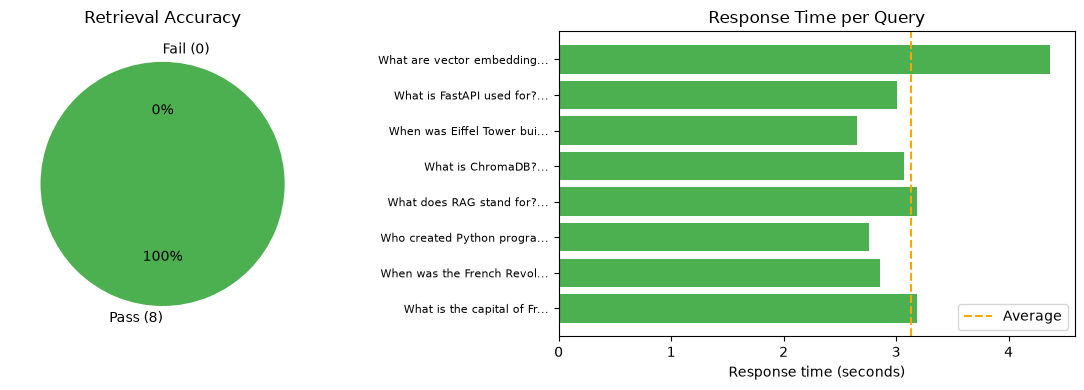

Evaluation chart saved!


In [13]:
# Results visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy pie chart
failed = len(results) - correct
ax1.pie(
    [correct, failed],
    labels=[f'Pass ({correct})', f'Fail ({failed})'],
    colors=['#4CAF50', '#EF5350'],
    autopct='%1.0f%%',
    startangle=90
)
ax1.set_title('Retrieval Accuracy')

# Response time bar chart
times = [r['time'] for r in results]
labels = [r['question'][:25] + '...' for r in results]
colors = ['#4CAF50' if r.get('passed') else '#EF5350' for r in results]

ax2.barh(range(len(times)), times, color=colors)
ax2.set_yticks(range(len(labels)))
ax2.set_yticklabels(labels, fontsize=8)
ax2.set_xlabel('Response time (seconds)')
ax2.set_title('Response Time per Query')
ax2.axvline(x=sum(times)/len(times), color='orange', linestyle='--', label='Average')
ax2.legend()

plt.tight_layout()
plt.savefig('retrieval_eval.png', dpi=100, bbox_inches='tight')
plt.show()
print('Evaluation chart saved!')

In [14]:
# Top-K experiment — kitne chunks retrieve karne chahiye?
model = SentenceTransformer('all-MiniLM-L6-v2')
client = chromadb.PersistentClient(path=CHROMA_PATH)

try:
    collection = client.get_collection('documents')
    total_docs = collection.count()
    print(f'ChromaDB mein total chunks: {total_docs}')

    test_query = 'What is machine learning?'
    qvec = model.encode([test_query])[0].tolist()

    print(f'\nQuery: "{test_query}"')
    print('Top-K results:')
    print('=' * 50)

    for k in [3, 5, 8, 10]:
        results_k = collection.query(
            query_embeddings=[qvec],
            n_results=min(k, total_docs)
        )
        chunks = results_k['documents'][0]
        total_chars = sum(len(c) for c in chunks)
        print(f'K={k:2d} | Chunks: {len(chunks)} | Total chars: {total_chars:5d} | Approx tokens: {total_chars//4}')

    print()
    print('Recommendation: K=5 for specific questions, K=8 for summaries')
except Exception as e:
    print(f'ChromaDB access error: {e}')
    print('Upload a document first via the API')

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


ChromaDB mein total chunks: 2626

Query: "What is machine learning?"
Top-K results:
K= 3 | Chunks: 3 | Total chars:   844 | Approx tokens: 211
K= 5 | Chunks: 5 | Total chars:  1406 | Approx tokens: 351
K= 8 | Chunks: 8 | Total chars:  2258 | Approx tokens: 564
K=10 | Chunks: 10 | Total chars:  2850 | Approx tokens: 712

Recommendation: K=5 for specific questions, K=8 for summaries


In [16]:
# Final report
print('=' * 60)
print('FINAL EVALUATION REPORT')
print('=' * 60)
print()
passed_q = [r for r in results if r.get('passed')]
failed_q = [r for r in results if not r.get('passed')]

print(f'Total questions  : {len(results)}')
print(f'Passed           : {len(passed_q)}')
print(f'Failed           : {len(failed_q)}')
print(f'Accuracy         : {len(passed_q)/len(results)*100:.1f}%')
print()

if failed_q:
    print('Failed questions (improve karne wale):')
    for r in failed_q:
        print(f'  - {r["question"]}')
    print()
    print('Fix suggestions:')
    print('  1. Chunk size kam karo (300 try karo)')
    print('  2. TOP_K badhao (8 ya 10 try karo)')
    print('  3. Prompt improve karo in llm_service.py')
else:
    print('All Questions Pass! RAG pipeline work Good.')

FINAL EVALUATION REPORT

Total questions  : 8
Passed           : 8
Failed           : 0
Accuracy         : 100.0%

All Questions Pass! RAG pipeline work Good.
